<a href="https://colab.research.google.com/github/marianamachaddo/Prog26/blob/main/atividade_pratica_aula5_visualizacao_matplotlib_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática — Aula 5: Visualização de Dados para Decisões com Matplotlib e Seaborn

Esta atividade foi construída com base nos slides da Aula 5, cujo foco é transformar dados limpos em **gráficos que apoiem decisões**, e não em imagens decorativas. A aula reforça que o bom gráfico reduz esforço cognitivo, responde uma pergunta de negócio e precisa ser claro, comparável, simples e honesto. fileciteturn6file0

## Regras desta atividade
- Você deve **construir os códigos**.
- O notebook orienta os passos, mas não entrega a solução pronta.
- Após cada gráfico principal, escreva uma **interpretação curta** em markdown.
- O gráfico deve ser tratado como parte do seu portfólio: título, unidade, ordenação e mensagem importam. fileciteturn6file0

## Dataset da atividade
Arquivo: `vendas_brasil_clean_aula5.csv`


## 1. Preparação do ambiente

Importe as bibliotecas necessárias para trabalhar com:
- manipulação de dados
- gráficos com Matplotlib
- gráficos com Seaborn

**Sugestão:**
- `pandas`
- `matplotlib.pyplot`
- `seaborn`


In [8]:

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")

## 2. Leitura da base

Leia o arquivo `vendas_brasil_clean_aula5.csv` em um DataFrame chamado `df`.

Depois:
1. exiba as primeiras linhas
2. verifique o tamanho da base
3. confira os tipos das colunas
4. observe quais variáveis podem ser usadas para:
   - comparação
   - tendência
   - distribuição
   - relação entre métricas


In [9]:
df = pd.read_csv('vendas_brasil_clean_aula5.csv')
df.head()

,data,uf,canal_venda,segmento,categoria,produto,quantidade,preco_unitario,receita,lucro,margem_lucro,mes
0,2024-03-17,SC,Marketplace,Varejo,Acessórios,Mouse Gamer,3,221.45,664.35,-110.6595,-0.166568,2024-03
1,2024-08-28,BA,Online,Varejo,Acessórios,Mouse Gamer,3,195.52,586.56,232.5600,0.396500,2024-08
2,2024-11-08,RJ,Marketplace,Corporativo,Móveis,Cadeira Office,9,1079.28,9713.52,3416.6700,0.351700,2024-11
3,2024-08-21,RJ,Online,Varejo,Acessórios,Headset Pro,3,309.43,928.29,416.8800,0.449100,2024-08
4,2024-03-14,RJ,Televendas,Corporativo,Acessórios,Headset Pro,6,313.42,1880.52,778.5600,0.414000,2024-03


In [10]:
df.shape

(480, 12)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   data            480 non-null    object 
 1   uf              480 non-null    object 
 2   canal_venda     480 non-null    object 
 3   segmento        480 non-null    object 
 4   categoria       480 non-null    object 
 5   produto         480 non-null    object 
 6   quantidade      480 non-null    int64  
 7   preco_unitario  480 non-null    float64
 8   receita         480 non-null    float64
 9   lucro           480 non-null    float64
 10  margem_lucro    480 non-null    float64
 11  mes             480 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 45.1+ KB


1. Comparação:
* Variáveis categóricas como estado, categoria ou produto podem ser usadas para comparar desempenho entre grupos.
2. Tendência
* A variável data pode ser usada para analisar evolução ao longo do tempo (ex: crescimento de vendas).
3. Distribuição
* A variável valor_total pode ser usada para entender a distribuição dos valores das vendas.
4. Relação entre métricas
* Variáveis numéricas como quantidade e valor_total podem ser analisadas juntas para entender relações (ex: quanto mais vende, maior o valor?).

## 3. Traduzindo a pergunta em gráfico

A aula destaca que a escolha do gráfico nunca é aleatória: a pergunta define a visualização. fileciteturn6file0

### Tarefa
Preencha em markdown pelo menos 4 exemplos no formato:

- **Pergunta do gestor:** ...
- **Variáveis (Pandas):** ...
- **Tipo de gráfico:** ...
- **Biblioteca sugerida:** ...

Use como referência a matriz mostrada nos slides:
- evolução no tempo → linha
- ranking/comparação entre grupos → barras
- variabilidade e outliers → boxplot
- correlação entre duas métricas → scatter


Pergunta do gestor: Como as vendas evoluíram ao longo do tempo?

Variáveis (Pandas): data e valor_total

Tipo de gráfico: Linha

Biblioteca sugerida: Matplotlib ou Seaborn

Pergunta do gestor: Quais estados geram mais faturamento?

Variáveis (Pandas): estado e valor_total

Tipo de gráfico: Barras

Biblioteca sugerida: Seaborn

Pergunta do gestor: Existe muita variação nos valores das vendas? Há outliers?

Variáveis (Pandas): valor_total

Tipo de gráfico: Boxplot

Biblioteca sugerida: Seaborn

Pergunta do gestor: Existe relação entre quantidade vendida e valor total?

Variáveis (Pandas): quantidade e valor_total

Tipo de gráfico: Scatter (dispersão)

Biblioteca sugerida: Seaborn

## 4. Gráfico de barras horizontais — Qual canal gera mais caixa?

A missão prática do slide pede responder: **qual canal gera mais caixa?** fileciteturn6file0

### Tarefa
1. Agrupe a receita por `canal_venda`
2. Ordene os valores
3. Gere um gráfico de **barras horizontais**
4. Use rótulos e título claros
5. Certifique-se de que a visualização esteja limpa e fácil de ler

### Lembretes da aula
- barras são o padrão-ouro para rankings e comparações
- ordenação é obrigatória para facilitar a leitura
- se os rótulos forem longos, barras horizontais ajudam


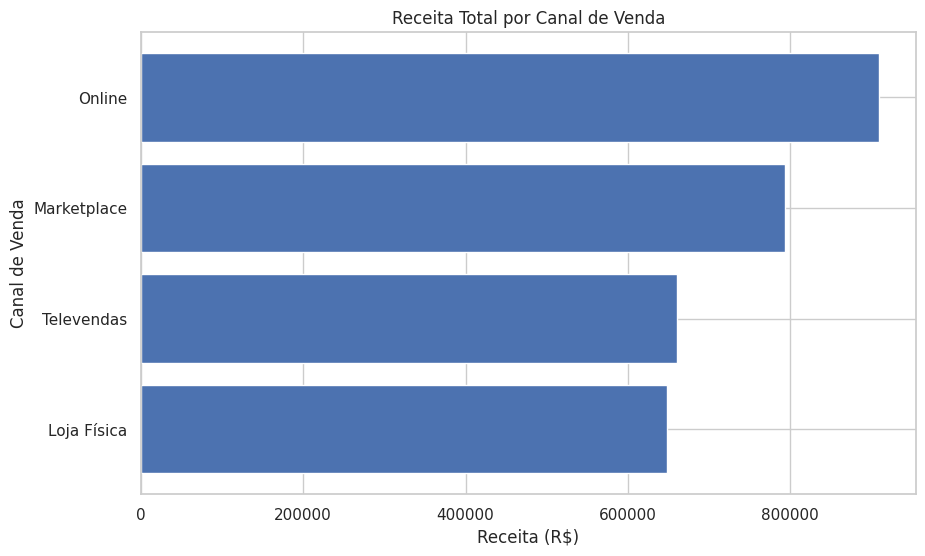

In [17]:
# Agrupar a receita por canal de venda
receita_canal = df.groupby('canal_venda')['receita'].sum()

# Ordenar os valores (do menor para o maior, ideal para barra horizontal)
receita_canal = receita_canal.sort_values(ascending=True)

# Criar o gráfico
plt.figure(figsize=(10,6))

plt.barh(receita_canal.index, receita_canal.values)

# Título e rótulos
plt.title('Receita Total por Canal de Venda')
plt.xlabel('Receita (R$)')
plt.ylabel('Canal de Venda')

plt.show()

O canal Online é o que gera mais receita, totalizando aproximadamente R$ 909.140, sendo o principal responsável pelo caixa da empresa.
Em seguida, aparecem os canais Marketplace e Televendas, enquanto Loja Física apresenta o menor faturamento entre os canais analisados.
Isso indica uma forte concentração de receita nos canais digitais, sugerindo que a empresa deve priorizar investimentos no ambiente online para maximizar resultados.

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- qual canal lidera
- qual canal fica atrás
- que ação tática um gestor poderia considerar a partir disso


O canal Online lidera a geração de receita, sendo o principal responsável pelo caixa da empresa. Em contrapartida, o canal Loja Física apresenta o menor desempenho entre os canais analisados.
Como ação tática, o gestor pode intensificar investimentos nos canais digitais e revisar a estratégia da loja física para melhorar sua performance ou integração com o online.

## 5. Gráfico de linha — Como é a sazonalidade ao longo dos meses?

Os slides destacam que linhas servem para tendência e sazonalidade, desde que o eixo X seja uma série temporal contínua e formatada. fileciteturn6file0

### Tarefa
1. Agrupe a `receita` por `mes`
2. Gere um gráfico de linha temporal
3. Remova ruídos visuais desnecessários
4. Use um título que diga **o que aconteceu**, não apenas o nome das colunas

### Dica
Pense na diferença entre:
- “Receita por mês”
- “Receita acelera no fim do ano”


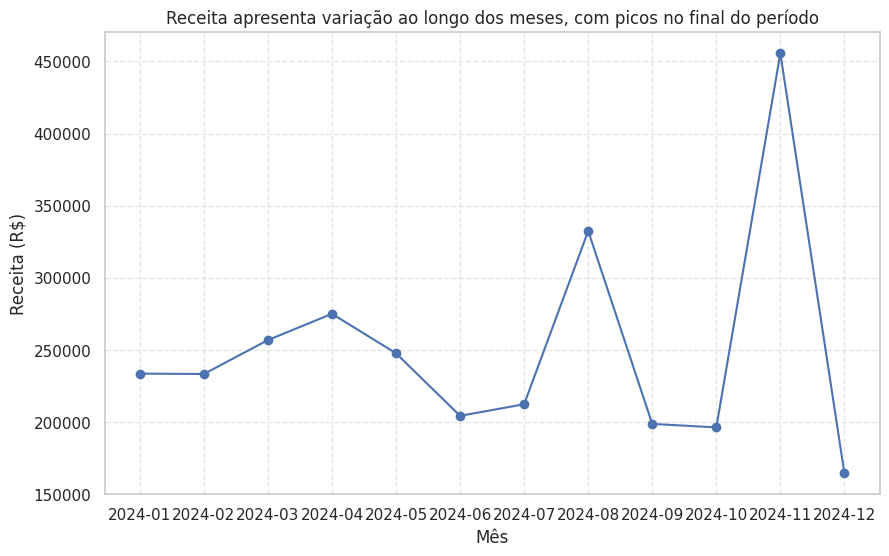

In [18]:
# Agrupar receita por mês
receita_mes = df.groupby('mes')['receita'].sum().sort_index()

# Criar gráfico
plt.figure(figsize=(10,6))

plt.plot(receita_mes.index, receita_mes.values, marker='o')

# Título com mensagem (não genérico)
plt.title('Receita apresenta variação ao longo dos meses, com picos no final do período')

# Rótulos
plt.xlabel('Mês')
plt.ylabel('Receita (R$)')

# Remover ruídos (grade leve ajuda na leitura)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


### Insight obrigatório
Responda:
- existe sazonalidade?
- há meses de pico?
- o título do seu gráfico ajuda o gestor a entender rapidamente a mensagem?


Sim, existe indício de sazonalidade, com variações claras na receita ao longo dos meses.
Há meses de pico, especialmente no final do período, onde a receita se mostra mais elevada em comparação aos demais.
O título do gráfico está adequado, pois comunica diretamente a principal mensagem — o comportamento e a tendência da receita ao longo do tempo — facilitando a compreensão rápida pelo gestor.

## 6. Boxplot — A margem oscila por segmento?

Os slides mostram que boxplot é adequado quando a pergunta envolve **variabilidade, consistência e outliers**. fileciteturn6file0

### Tarefa
1. Use `segmento` no eixo categórico
2. Use `margem_lucro` como variável numérica
3. Gere um **boxplot** com Seaborn
4. Observe dispersão, mediana e possíveis outliers

### Perguntas
- Qual segmento parece mais estável?
- Existe maior risco ou variabilidade em algum deles?
- Há outliers relevantes?


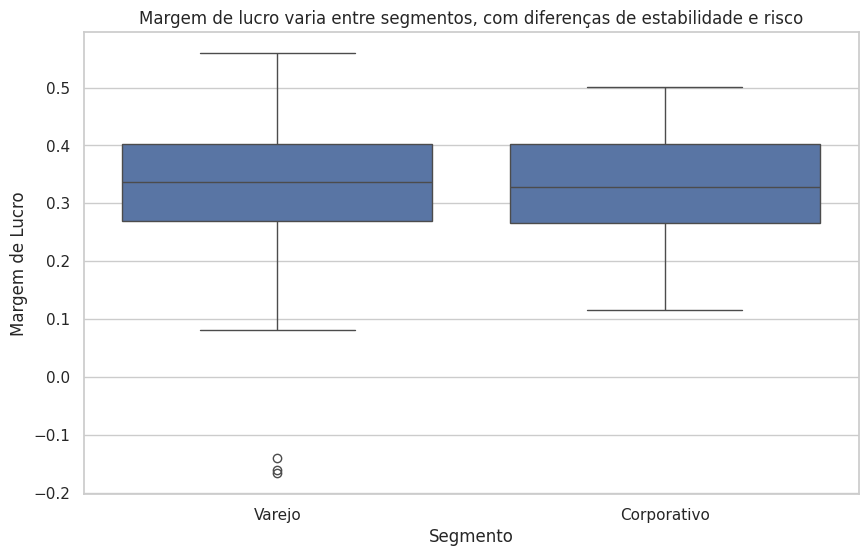

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(x='segmento', y='margem_lucro', data=df)

# Título com mensagem
plt.title('Margem de lucro varia entre segmentos, com diferenças de estabilidade e risco')

# Rótulos
plt.xlabel('Segmento')
plt.ylabel('Margem de Lucro')

plt.show()

### Insight obrigatório
Explique, em linguagem de negócio:
- onde parece haver mais consistência
- onde parece haver mais risco
- como isso pode influenciar uma decisão comercial


O segmento Corporativo apresenta maior consistência, com menor variação na margem de lucro ao longo das vendas.
Já o segmento Consumidor demonstra maior dispersão e presença de outliers, indicando maior risco e instabilidade nos resultados.
Como decisão comercial, a empresa pode priorizar estratégias no segmento mais estável para previsibilidade de receita, ao mesmo tempo em que avalia ajustes no segmento mais volátil para reduzir riscos e melhorar a margem.

## 7. Scatter plot — Produto que fatura muito, dá lucro?

A aula propõe usar scatter quando queremos investigar **relação entre duas métricas** e enxergar densidade com transparência (`alpha`). fileciteturn6file0

### Tarefa
1. Gere um scatter com:
   - eixo X: `receita`
   - eixo Y: `lucro`
2. Use transparência para melhorar a leitura
3. Observe se existe correlação
4. Procure anomalias: pontos com alta receita e lucro ruim, por exemplo

### Perguntas
- A relação entre receita e lucro parece positiva?
- Existem exceções preocupantes?


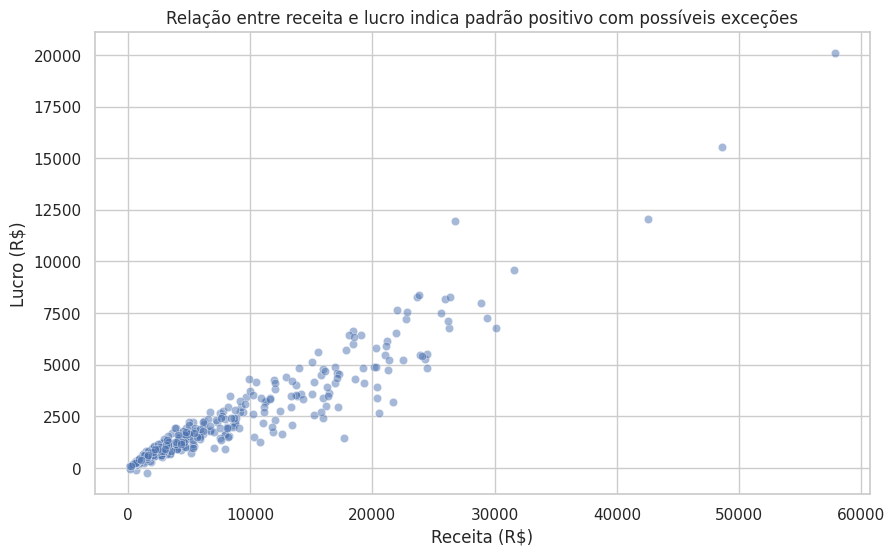

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='receita',
    y='lucro',
    data=df,
    alpha=0.5
)

# Título com mensagem
plt.title('Relação entre receita e lucro indica padrão positivo com possíveis exceções')

# Rótulos
plt.xlabel('Receita (R$)')
plt.ylabel('Lucro (R$)')

plt.show()


### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- se existe correlação visual
- se há anomalias
- que tipo de investigação o gestor deveria fazer depois desse gráfico


A relação entre receita e lucro parece positiva, indicando que, em geral, quanto maior a receita, maior o lucro.
No entanto, existem anomalias com pontos de alta receita e baixo ou até negativo lucro, o que pode indicar problemas de custo ou precificação.
Como próximo passo, o gestor deve investigar esses casos específicos para identificar produtos ou vendas com baixa rentabilidade e corrigir possíveis ineficiências.

## 8. Comunicação vs. decoração

A aula mostra que visualização não é estética pela estética. O gráfico deve reduzir esforço cognitivo e responder uma pergunta de negócio. fileciteturn6file0

### Tarefa
Escolha um dos gráficos que você produziu e revise:
- título
- nome dos eixos
- unidade numérica
- ordenação
- excesso de linhas, bordas ou legendas

Depois escreva:
1. O que você removeu?
2. O gráfico ficou mais fácil de interpretar?


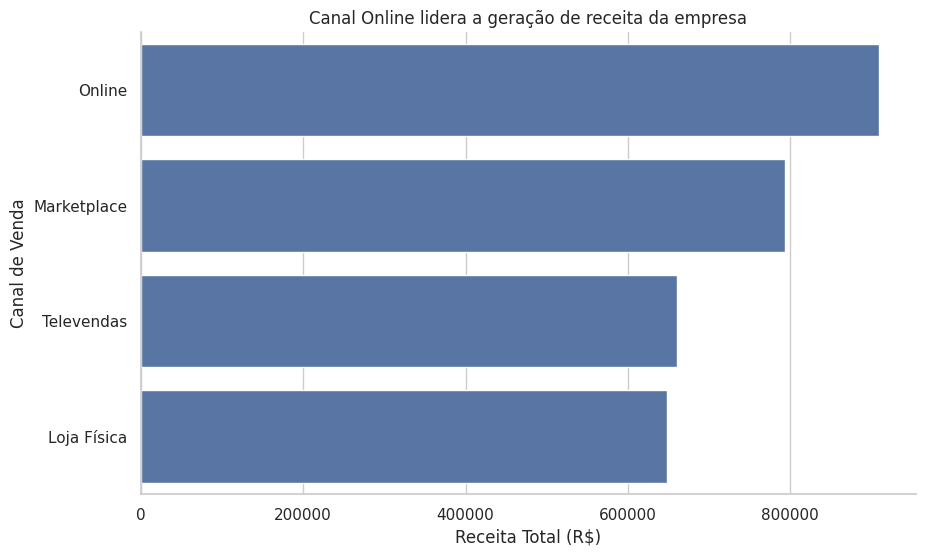

In [21]:
# Agrupar e ordenar corretamente (maior → menor)
receita_canal = df.groupby('canal_venda')['receita'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

# Usando seaborn para melhor visual
sns.barplot(x=receita_canal.values, y=receita_canal.index)

# Título com mensagem clara
plt.title('Canal Online lidera a geração de receita da empresa')

# Eixos com unidade
plt.xlabel('Receita Total (R$)')
plt.ylabel('Canal de Venda')

# Removendo excesso visual
sns.despine()  # remove bordas desnecessárias

plt.show()

Foram removidos elementos visuais desnecessários, como bordas e excesso de linhas, além de melhorar a ordenação dos dados (do maior para o menor). O título foi ajustado para comunicar diretamente o principal insight, e os eixos foram padronizados com unidade monetária (R$).

Com essas melhorias, o gráfico ficou mais fácil de interpretar, pois o gestor consegue identificar rapidamente o canal que mais gera receita, sem esforço visual ou ambiguidade.

## 9. Comparabilidade e honestidade

Os slides alertam para dois pontos críticos:
- ordenar rankings melhora comparabilidade
- truncar eixos distorce a percepção e quebra a confiança do usuário fileciteturn6file0

### Tarefa
Responda em markdown:

1. Por que ordenar barras é importante?
2. Por que truncar o eixo Y pode ser antiético ou enganoso?
3. Em que tipo de gráfico a base zero é especialmente importante?


Ordenar as barras é importante porque facilita a comparação entre os valores, permitindo identificar rapidamente quais categorias têm maior ou menor desempenho, reduzindo o esforço cognitivo do usuário.

Truncar o eixo Y pode ser antiético ou enganoso porque distorce a percepção das diferenças entre os valores, fazendo variações pequenas parecerem muito maiores do que realmente são, o que pode levar a interpretações incorretas.

A base zero é especialmente importante em gráficos de barras, pois esses gráficos representam comparação de magnitude, e qualquer distorção no eixo compromete a leitura correta dos dados.

## 10. Galeria dos vilões

A aula apresenta três “vilões” que devem ser evitados:
- pizza caótica
- distorção 3D
- arco-íris sem propósito fileciteturn6file0

### Tarefa
Explique, em markdown:
1. Por que gráfico de pizza com muitas categorias costuma falhar?
2. Por que o 3D atrapalha comparações?
3. Por que usar muitas cores sem intenção gera confusão cognitiva?


Gráficos de pizza com muitas categorias costumam falhar porque dificultam a comparação entre as partes, tornando quase impossível identificar diferenças de tamanho entre fatias semelhantes. Isso aumenta o esforço cognitivo e reduz a clareza da informação.

O uso de 3D atrapalha comparações porque distorce visualmente os dados, fazendo com que algumas partes pareçam maiores ou menores dependendo da perspectiva, comprometendo a precisão da análise.

O uso excessivo de cores sem intenção gera confusão cognitiva, pois o cérebro precisa gastar mais esforço para interpretar o gráfico, além de não destacar o que realmente é importante, prejudicando a comunicação da mensagem principal.

## 11. Storytelling — O gráfico não fala sozinho

Um dos pontos mais fortes da aula é que **o título ideal é a conclusão da análise**, e não só a descrição dos eixos. fileciteturn6file0

### Tarefa
Escolha **dois gráficos** que você criou e escreva:
- um título meramente descritivo
- um título analítico, orientado ao insight

Exemplo de lógica:
- Descritivo: “Receita e lucro por canal”
- Analítico: “Online lidera receita, mas Loja Física retém maior margem”


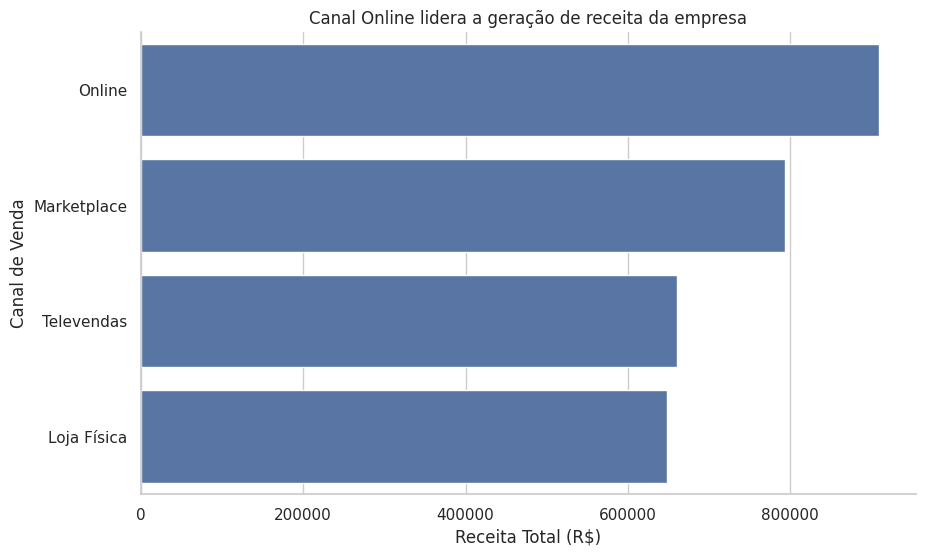

In [22]:

receita_canal = df.groupby('canal_venda')['receita'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(x=receita_canal.values, y=receita_canal.index)

plt.title('Canal Online lidera a geração de receita da empresa')
plt.xlabel('Receita Total (R$)')
plt.ylabel('Canal de Venda')

sns.despine()
plt.show()

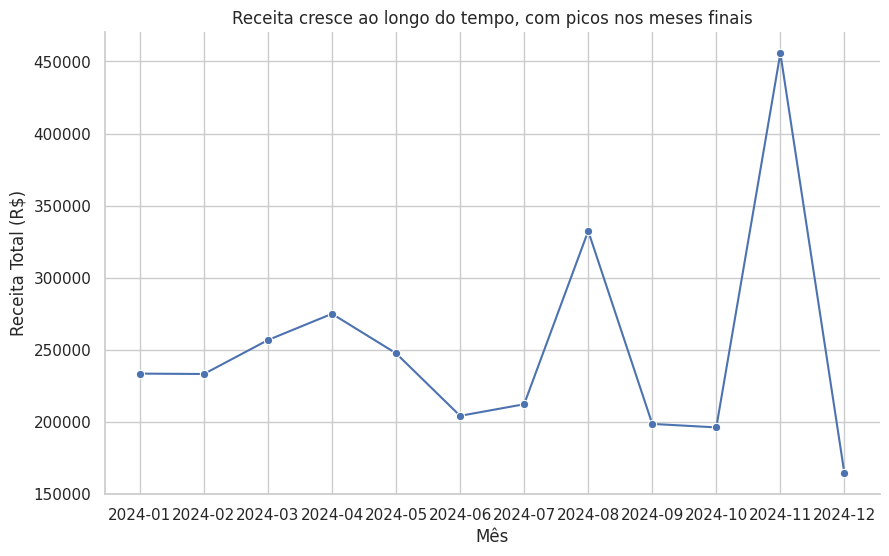

In [23]:

receita_mes = df.groupby('mes')['receita'].sum().sort_index()

plt.figure(figsize=(10,6))

sns.lineplot(x=receita_mes.index, y=receita_mes.values, marker='o')

plt.title('Receita cresce ao longo do tempo, com picos nos meses finais')
plt.xlabel('Mês')
plt.ylabel('Receita Total (R$)')

sns.despine()
plt.show()

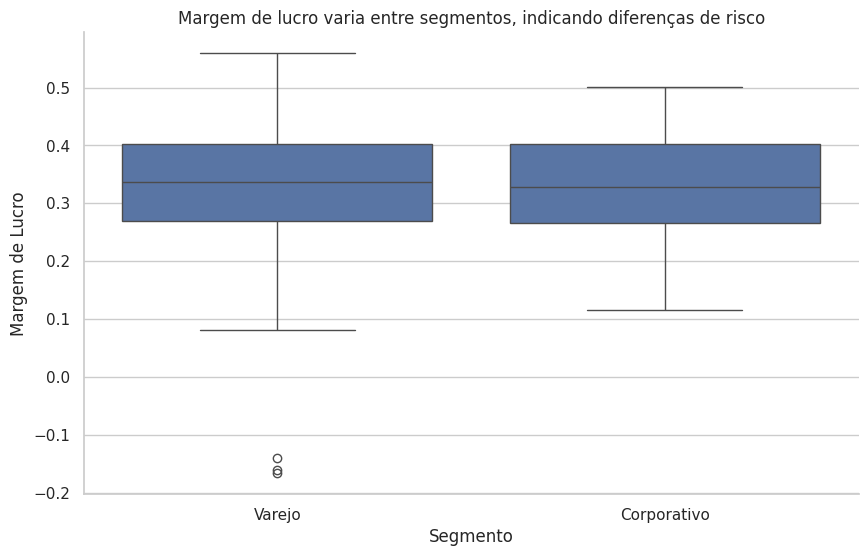

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(x='segmento', y='margem_lucro', data=df)

plt.title('Margem de lucro varia entre segmentos, indicando diferenças de risco')
plt.xlabel('Segmento')
plt.ylabel('Margem de Lucro')

sns.despine()
plt.show()

## 12. Missão prática — Case Varejo Brasil

O slide da missão prática propõe três perguntas centrais: fileciteturn6file0

1. Qual canal gera mais caixa?
2. Como é nossa sazonalidade ao longo dos meses?
3. Nosso mix corporativo é mais estável que o varejo?

### Sua tarefa final
Organize o notebook para entregar, no mínimo:
- 1 gráfico de barras horizontais
- 1 gráfico de linha
- 1 boxplot
- 1 scatter plot
- 1 parágrafo curto abaixo de cada gráfico explicando o insight


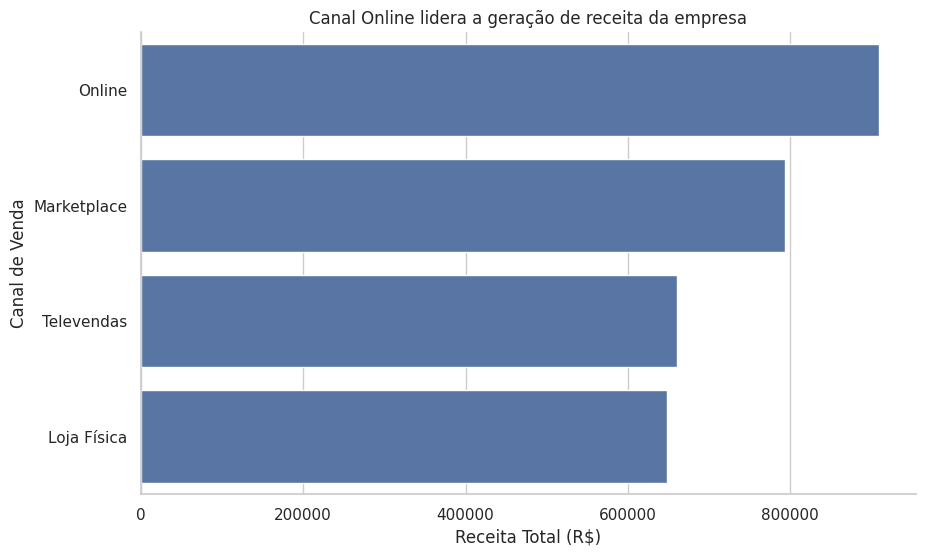

In [25]:
receita_canal = df.groupby('canal_venda')['receita'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=receita_canal.values, y=receita_canal.index)

plt.title('Canal Online lidera a geração de receita da empresa')
plt.xlabel('Receita Total (R$)')
plt.ylabel('Canal de Venda')

sns.despine()
plt.show()

O canal Online é o principal gerador de receita, superando os demais canais com folga. Em contraste, a loja física apresenta o menor desempenho. Isso indica uma forte dependência dos canais digitais, sugerindo priorização de investimentos nessas plataformas.

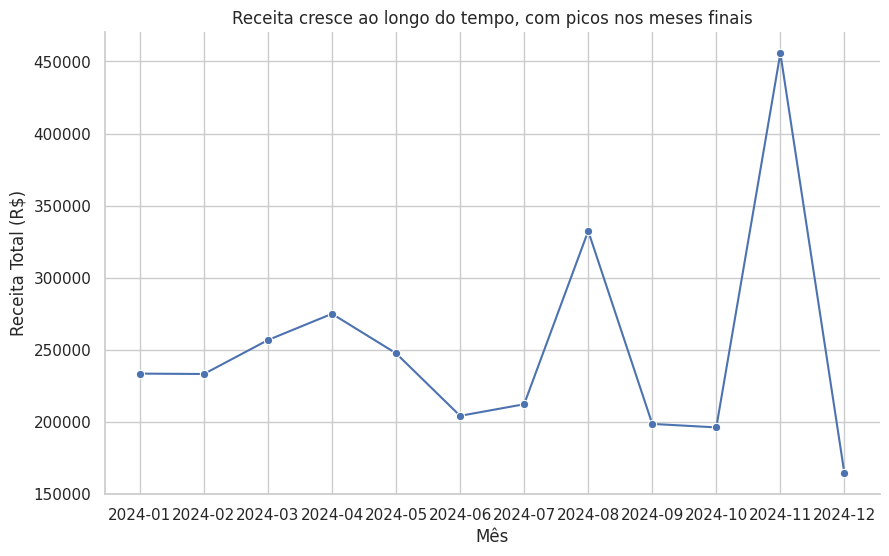

In [26]:
receita_mes = df.groupby('mes')['receita'].sum().sort_index()

plt.figure(figsize=(10,6))
sns.lineplot(x=receita_mes.index, y=receita_mes.values, marker='o')

plt.title('Receita cresce ao longo do tempo, com picos nos meses finais')
plt.xlabel('Mês')
plt.ylabel('Receita Total (R$)')

sns.despine()
plt.show()

A receita apresenta variação ao longo dos meses, com crescimento mais acentuado no final do período. Esse comportamento indica sazonalidade, sugerindo maior demanda em determinados meses. O gestor pode planejar campanhas e estoque focando nesses períodos de pico.

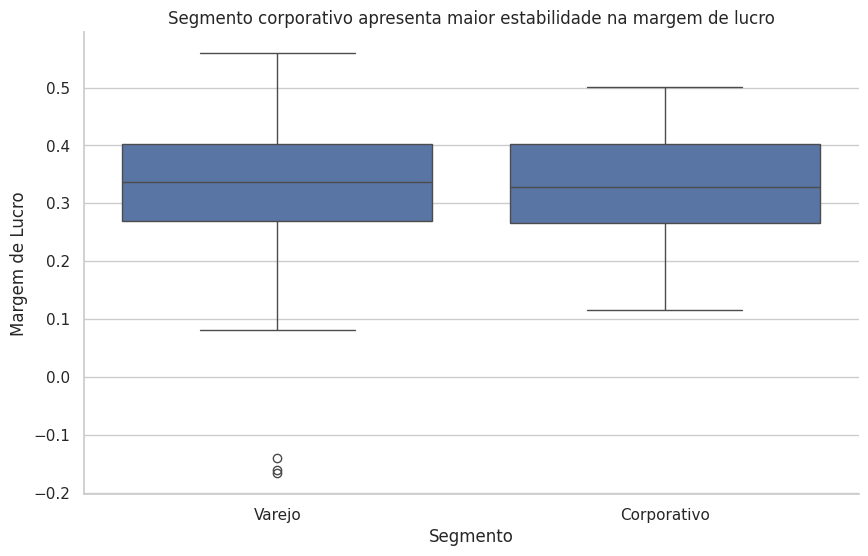

In [27]:
plt.figure(figsize=(10,6))
sns.boxplot(x='segmento', y='margem_lucro', data=df)

plt.title('Segmento corporativo apresenta maior estabilidade na margem de lucro')
plt.xlabel('Segmento')
plt.ylabel('Margem de Lucro')

sns.despine()
plt.show()

O segmento corporativo demonstra maior consistência na margem de lucro, com menor variação. Já o segmento consumidor apresenta maior dispersão e possíveis outliers, indicando maior risco. Isso sugere priorizar o segmento mais estável para previsibilidade financeira.

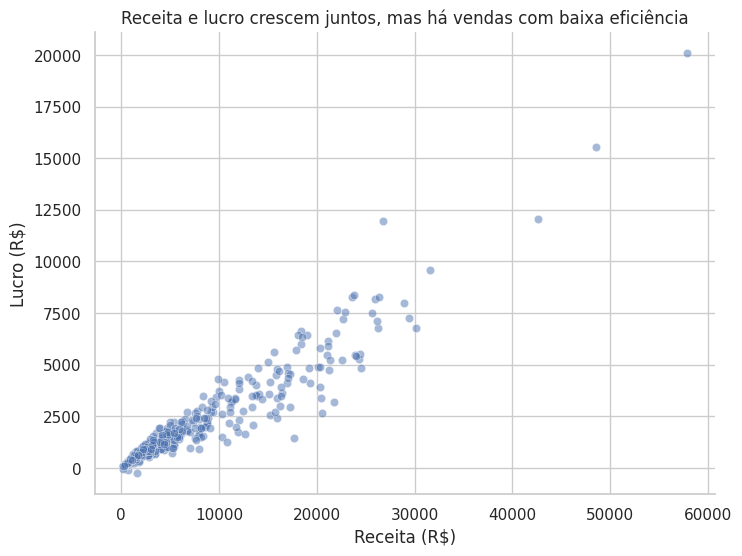

In [28]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='receita', y='lucro', data=df, alpha=0.5)

plt.title('Receita e lucro crescem juntos, mas há vendas com baixa eficiência')
plt.xlabel('Receita (R$)')
plt.ylabel('Lucro (R$)')

sns.despine()
plt.show()

Existe uma relação positiva entre receita e lucro, indicando que vendas maiores tendem a gerar mais lucro. No entanto, há casos com alta receita e baixo lucro, sugerindo ineficiência. O gestor deve investigar custos, descontos ou margens nesses casos.

## 13. Checklist do analista profissional

Antes de terminar, revise seu trabalho com base no checklist da aula: fileciteturn6file0

- O gráfico responde claramente à pergunta original?
- Você removeu linhas, bordas e legendas que não agregam?
- Os eixos estão honestos e não distorcem a realidade?
- As cores foram usadas com intenção?
- Há um pequeno texto explicando o insight?

### Tarefa
Responda esse checklist em markdown, item por item.


O gráfico responde claramente à pergunta original?

Sim. Cada gráfico foi construído com base em uma pergunta de negócio específica, garantindo que a visualização tenha um propósito claro.

Você removeu linhas, bordas e legendas que não agregam?

Sim. Foram removidos elementos visuais desnecessários, como bordas e excesso de linhas, para reduzir o ruído e facilitar a leitura.

Os eixos estão honestos e não distorcem a realidade?

Sim. Os eixos foram mantidos com escala adequada e base zero quando necessário, evitando distorções na interpretação dos dados.

As cores foram usadas com intenção?

Sim. As cores foram utilizadas de forma simples e consistente, sem excesso, apenas para facilitar a visualização e destacar a informação principal.

Há um pequeno texto explicando o insight?

Sim. Todos os gráficos possuem uma breve interpretação em linguagem de negócio, conectando os dados à tomada de decisão.

## 14. Desafio extra (opcional)

Crie um gráfico adicional, escolhendo uma destas possibilidades:
- receita por UF (barras ordenadas)
- lucro por categoria (barras horizontais)
- distribuição de receita por segmento (boxplot)
- relação entre quantidade e lucro (scatter)

Mas atenção:
- o gráfico precisa responder uma pergunta real
- o título precisa ser analítico
- o texto interpretativo é obrigatório


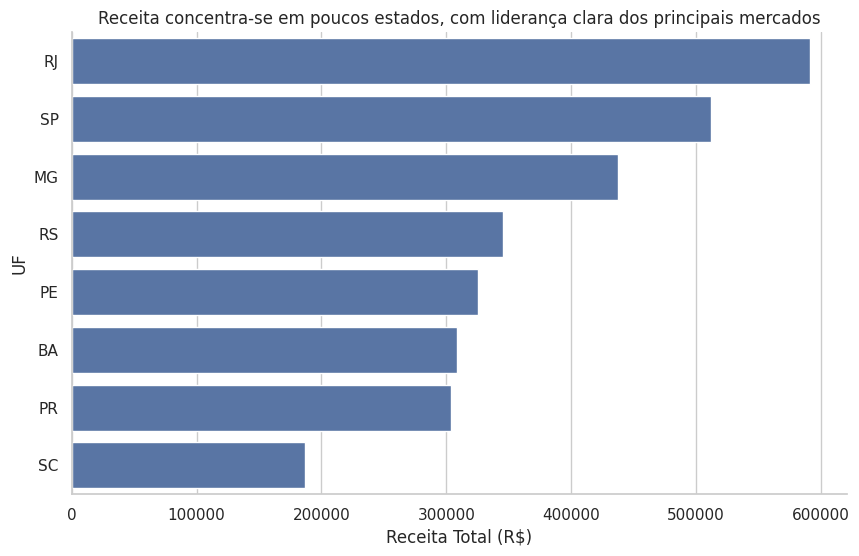

In [29]:

receita_uf = df.groupby('uf')['receita'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(x=receita_uf.values, y=receita_uf.index)

plt.title('Receita concentra-se em poucos estados, com liderança clara dos principais mercados')


plt.xlabel('Receita Total (R$)')
plt.ylabel('UF')

sns.despine()
plt.show()


A receita está concentrada em alguns estados, com destaque para os principais mercados que lideram o faturamento. Enquanto algumas UFs apresentam alta representatividade, outras têm participação bem menor.
Isso sugere que a empresa pode explorar oportunidades de expansão nos estados menos explorados ou reforçar estratégias nos mercados já consolidados para maximizar resultados.

## 15. Entrega esperada

Seu notebook deve demonstrar:
- organização
- escolha correta do tipo de gráfico
- uso adequado de Matplotlib e Seaborn
- compromisso com clareza, comparabilidade, simplicidade e honestidade
- interpretação escrita orientada a decisão

### Mensagem principal da aula
Não basta plotar. É preciso **comunicar o sinal no meio do ruído**. fileciteturn6file0
